# Parameter tuning for Terschelling

## Paths and settings

In [1]:
new_initial_state = False
new_tuning = False

In [2]:
path_tc = '/home/jovyan/data/98_paper2_kf_dtm/01_tides/output/'

path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/12_13_Ters_DEM/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/12_13_Ters_DEM/output/'
path_altimetry_output = '/home/jovyan/data/98_paper2_kf_dtm/11_Ters_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2023_n53.5439_s53.2693_w5.0194_e5.6607.nc'
fn_ddtm = 'DeltaDTM_v1_0_N53E005.tif'

# epsg = 28992 # Amersfoort
epsg = 4326 # WGS84

year_start = 1993
year_end = 2020 # included

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Static parameters

In [5]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Observations

In [6]:
# Altimetry
fn = 'tp_plus_ales_epsg28992.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [7]:
# Tidal correction
fn = 'tides_ters.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [8]:
# Cassie shorelines
folders = ['12_cassie_landsat_1984-04-30_1992-09-04_ext1000_spac5000_base2_multi-thresh/',\
          '13_cassie_landsat_1992-09-20_2003-08-02_ext1000_spac5000_base2_multi-thresh/',\
          '18_cassie_landsat_2003-09-19_2015-03-12_ext1300_spac5000_base1_multi-thresh/',\
          '17_cassie_landsat_2015-04-13_2023-02-22_ext1300_spac5000_base1_multi-thresh/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'/1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

118 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 790 points (min: 156, max: 1475).


## Initial state

In [9]:
resolution = 100 # [m], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_{resolution}m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    buffer_size = 500 # [m], buffer radius of target area around the set of shorelines
    smooth_factor = 100 # Smoothing of shorelines used to compute the median shoreline

    if epsg == 4326:
        buffer_size = CD_geometry.dist_meter_to_dist_deg(buffer_size) # [deg]
        resolution = CD_geometry.dist_meter_to_dist_deg(resolution) # [deg]

    # Target area
    # alpha (how much slack around the concave hull)
    if epsg == 4326:
        alpha = 100
    elif epsg == 28992:
        alpha = 3e-4    

    # Polgon around the shorelines
    poly_shorelines = CD_geometry.get_area_covered_by_shorelines(c_shorelines, alpha=alpha, buffer_size=0)

    # Polygon of target area (shoreline polygon with buffer)
    # poly_target = poly_shorelines.buffer(buffer_size)

    # Buffer around median shoreline 
    med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=100, transect_length=5000, smooth_factor=smooth_factor)
    poly_target = med_sl.buffer(buffer_size)

    # Buffer around zero-contour
    # poly_target = zcontour.buffer(buffer_size)

    pickle.dump(med_sl, open(path_output + f'med_sl{epsg}.pkl', 'wb'))
    pickle.dump(poly_target, open(path_output + f'poly_target{epsg}.pkl', 'wb'))
    pickle.dump(poly_shorelines, open(path_output + f'poly_sl_{epsg}.pkl', 'wb'))

    CD_kalman.initial_state(poly_target, med_sl, epsg, resolution, c_shorelines, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco, fn_ddtm)
else:
    med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb')) 
    poly_target = pickle.load(open(path_output + f'poly_target{epsg}.pkl', 'rb')) 
    poly_shorelines = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [10]:
init = xr.open_dataset(path_output+fn_init).squeeze()

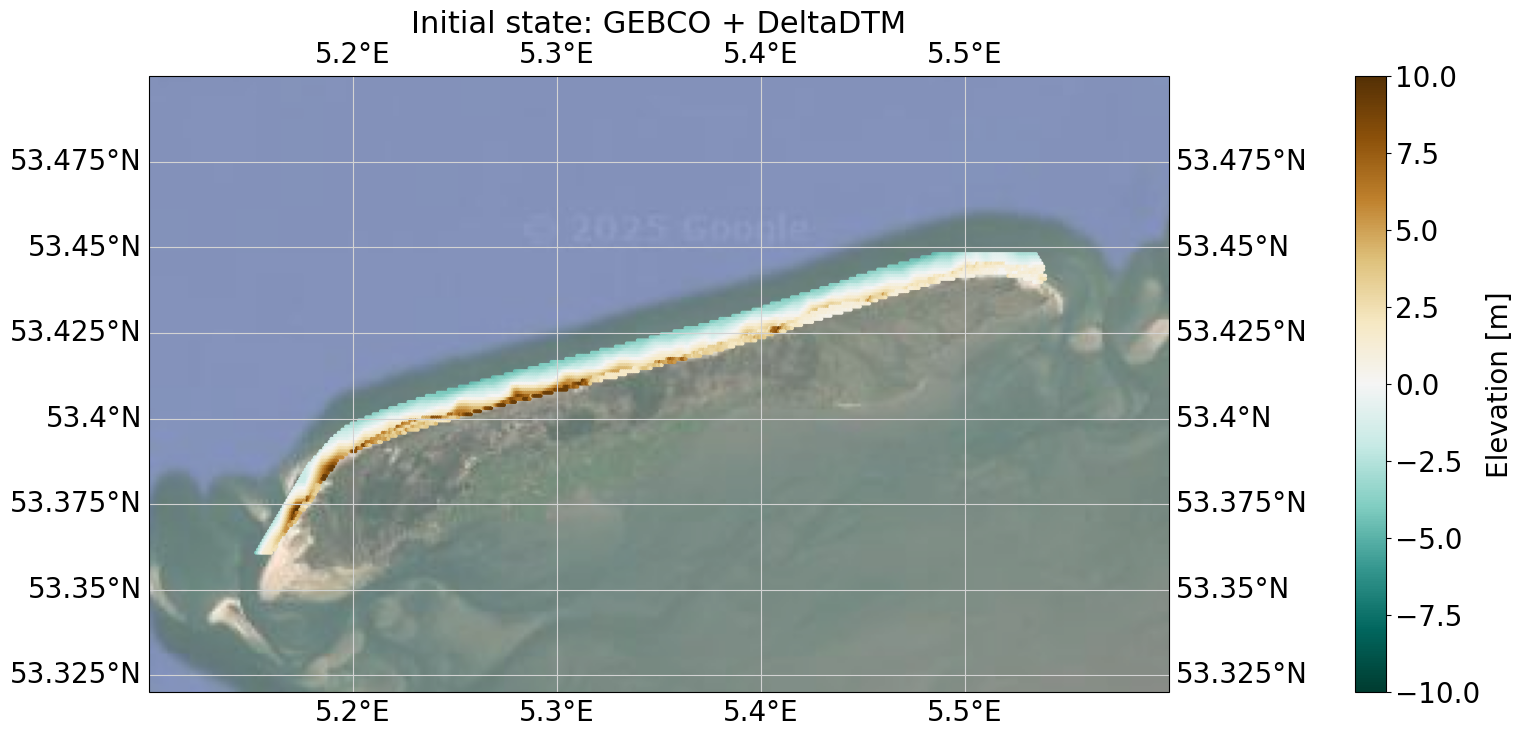

In [11]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

# %matplotlib qt5
projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=15,
                  cmap='BrBG_r', vmin=-10, vmax=10)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=22);

plt.savefig(f'{path_output}initial_state.png', dpi=300, bbox_inches='tight')

## Shoreline outlier rejection

In [12]:
# shoreline outlier rejection
init_df = init.to_dataframe().reset_index().dropna()
zcontour = CD_geometry.get_DEM_contour(init_df['x'], init_df['y'], init_df['band_data'], h=0, tarea=poly_target)

t_factor = .8 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, zcontour, epsg, t_factor)

28.999999999999996% of shoreline points were discarded.


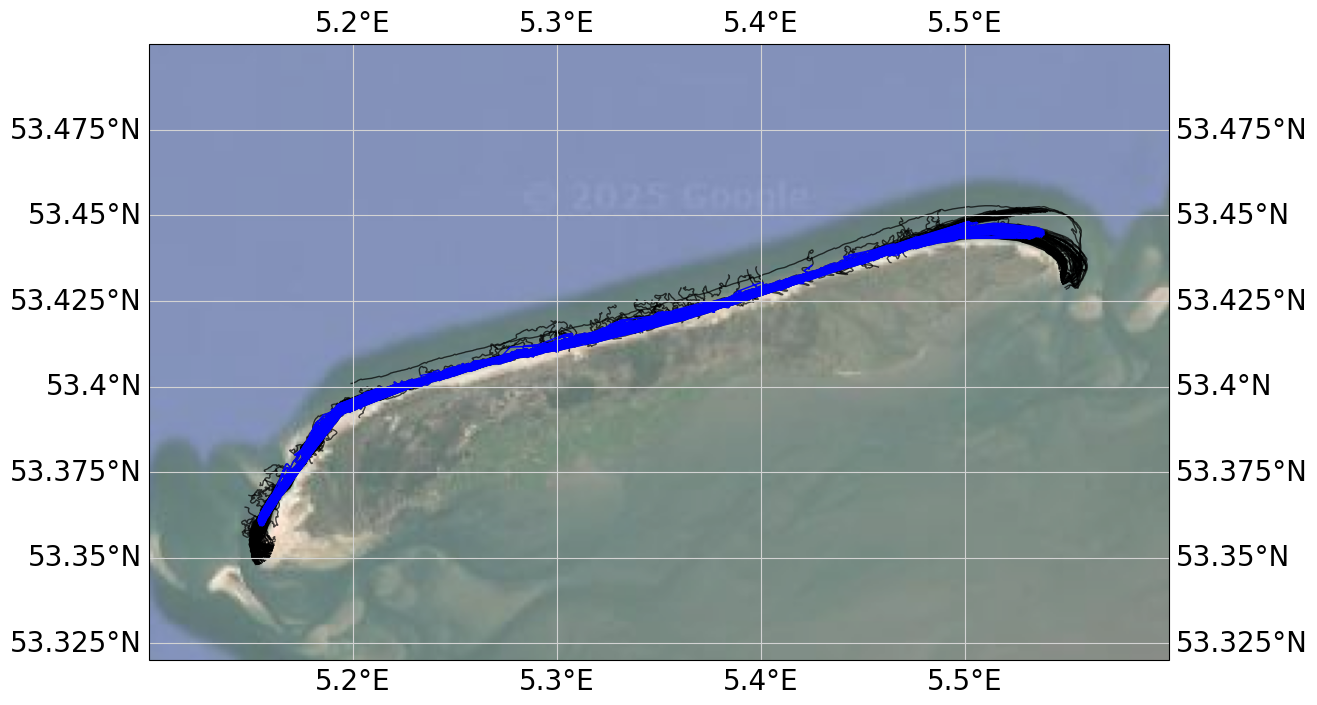

In [13]:
# Visual inspection of shoreline outlier rejection
%matplotlib inline

# projection = ccrs.epsg('28992')
projection = ccrs.PlateCarree()

request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

# ax.add_geometries(poly_shorelines, crs=projection, facecolor='none', edgecolor='orange')
# ax.add_geometries(poly_target, crs=projection, facecolor='none', edgecolor='black')

from shapely import LineString
for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='black', zorder=1, alpha=.7)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)

## Jarkus data

In [14]:
# moved this cell to function CD_jarkus_tools.get_jarkus_data
# still leave it here, because the jarkus xarray DataSet is needed for
# for dividing the areas for the volume changes
# jarkus_gdf = CD_jarkus_tools.get_jarkus_data(path_jarkus, year_start, year_end, poly_target, init)

# Jarkus data
jarkus = xr.open_dataset(path_input_general + 'transect_red_with_derivatives.nc')

# Reduce to Terschelling and the time after 1992
idx_alongshore, = np.where(jarkus.areacode == 4)
jarkus_years = pd.to_datetime(jarkus.time).year
idx_time, = np.where((jarkus_years >= year_start) & (jarkus_years <= year_end))
jarkus_years = jarkus_years[idx_time]
jarkus = jarkus.isel(alongshore = idx_alongshore, time = idx_time)

# Remove values coming from more than one source
jarkus['altitude_red'] = xr.where(jarkus.nsources <= 1, jarkus.altitude, np.nan)\
.assign_attrs({"description": "Values coming \"from more than one source\" are masked out based on variable nsources."})

# Jarkus GeoDataFrame
lon_jarkus = jarkus.lon.values.reshape(-1)
lat_jarkus = jarkus.lat.values.reshape(-1)

# x_jarkus = jarkus.x.values.reshape(-1)
# y_jarkus = jarkus.y.values.reshape(-1)

# reshape jarkus elevation to 2D, one timestep per row
jarkus_elev = jarkus['altitude_red'].values.reshape(len(jarkus.time), len(jarkus.alongshore)*len(jarkus.cross_shore))

jarkus_df = pd.DataFrame(jarkus_elev).T
jarkus_df.columns = jarkus_years
jarkus_gdf = gpd.GeoDataFrame(jarkus_df, geometry=gpd.points_from_xy(lon_jarkus, lat_jarkus))
# jarkus_gdf = gpd.GeoDataFrame(jarkus_df, geometry=gpd.points_from_xy(x_jarkus, y_jarkus))
jarkus_gdf.columns = jarkus_gdf.columns.astype(str)

# Reduce to target area
jarkus_gdf = jarkus_gdf[jarkus_gdf.intersects(poly_target)]

In [15]:
# thin out the grid so that there are approximately 700 values left, as evenly spaced as possible
temp = init.band_data.values.reshape(-1)
num_values = len(temp[~np.isnan(temp)])

thin_out_factor = int(len(jarkus_gdf) / num_values)
jarkus_gdf = jarkus_gdf.iloc[::thin_out_factor]

jarkus_gdf = jarkus_gdf.set_crs('4326')
jarkus_gdf = jarkus_gdf.reset_index(drop=True)

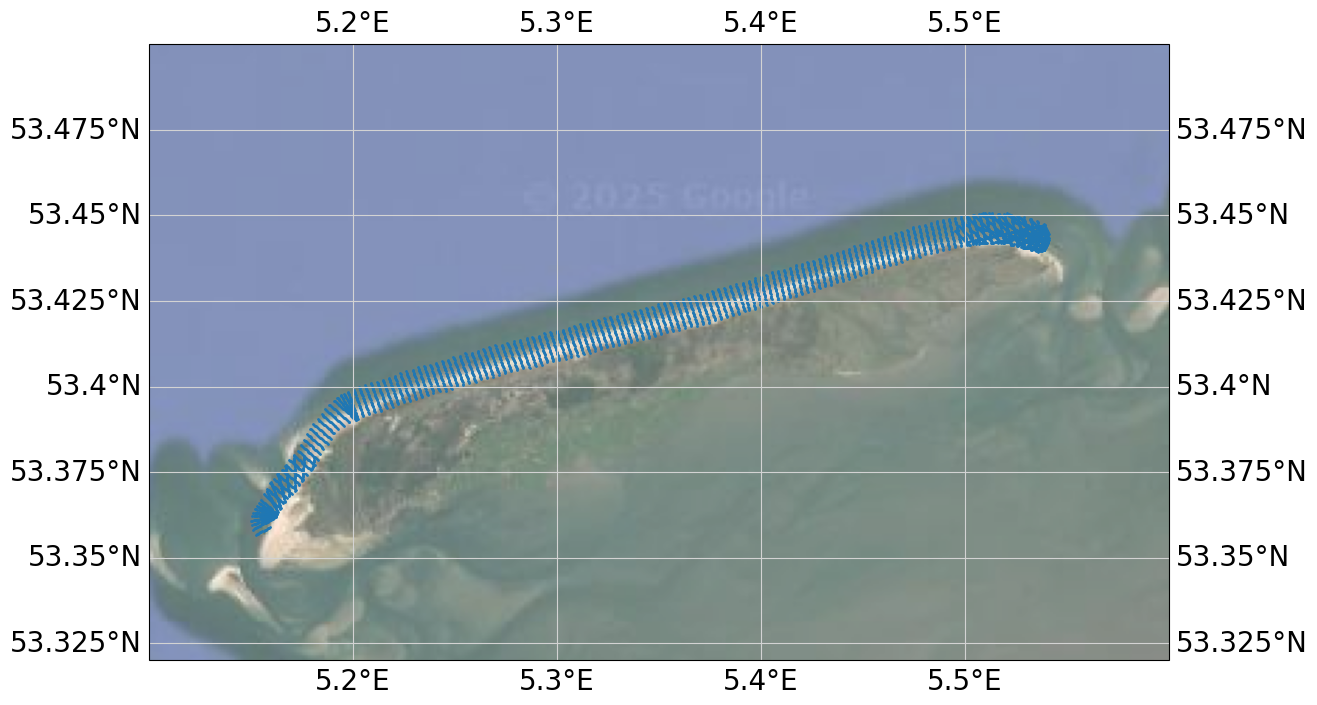

In [16]:
%matplotlib inline

# projection = ccrs.epsg('28992')
projection = ccrs.PlateCarree()

request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

ax.scatter(jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, s=1, transform=projection)

## Define areas for volume changes

In [17]:
poly_all, poly_west, poly_center, poly_east = CD_jarkus_tools.get_Ters_section_polygons(poly_target, jarkus, buffer_vol=-250)

Reduced target polygon by 50.4 %


In [18]:
pickle.dump(poly_all, open(path_output + f'poly_all_{epsg}.pkl', 'wb'))
pickle.dump(poly_west, open(path_output + f'poly_west_{epsg}.pkl', 'wb'))
pickle.dump(poly_center, open(path_output + f'poly_center{epsg}.pkl', 'wb'))
pickle.dump(poly_east, open(path_output + f'poly_east{epsg}.pkl', 'wb'))

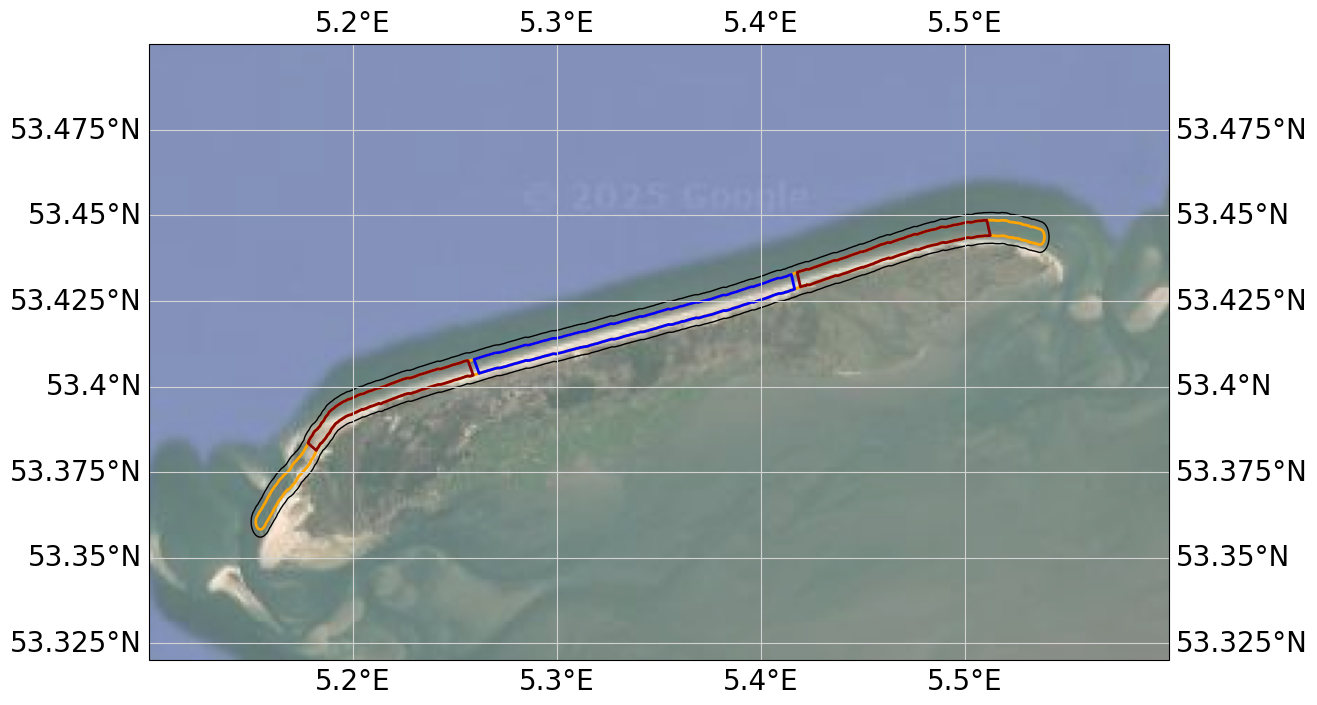

In [19]:
%matplotlib inline
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(15,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

ax.add_geometries(poly_target, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black')
ax.add_geometries(poly_all, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='orange', linewidth=2)
# ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='orange', linewidth=2)
ax.add_geometries(poly_west, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)
ax.add_geometries(poly_center, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='blue', linewidth=2)
ax.add_geometries(poly_east, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)

# ax.add_geometries(poly_west_out, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkgreen', linewidth=2)
# ax.add_geometries(poly_east_out, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkgreen', linewidth=2)

## Functions for volume changes

In [20]:
def volume_changes(x_state, x_state_s, jarkus_gdf, poly_all, poly_west, poly_center, poly_east):
    start_time = time.perf_counter()
    
    # Volumes for all (sub)areas
    year_list = [int(_) for _ in kf_interp.drop(columns='geometry').columns]

    volumes = pd.DataFrame(index=year_list)

    volumes['kf_all'] = CD_geometry.compute_volume_changes(x_state, poly_all, col_name='', epsg_out=28992)
    volumes['rts_all'] = CD_geometry.compute_volume_changes(x_state_s, poly_all, col_name='', epsg_out=28992)
    volumes['jarkus_all'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_all, col_name='', epsg_out=28992)

    volumes['kf_west'] = CD_geometry.compute_volume_changes(x_state, poly_west, col_name='', epsg_out=28992)
    volumes['rts_west'] = CD_geometry.compute_volume_changes(x_state_s, poly_west, col_name='', epsg_out=28992)
    volumes['jarkus_west'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_west, col_name='', epsg_out=28992)

    volumes['kf_center'] = CD_geometry.compute_volume_changes(x_state, poly_center, col_name='', epsg_out=28992)
    volumes['rts_center'] = CD_geometry.compute_volume_changes(x_state_s, poly_center, col_name='', epsg_out=28992)
    volumes['jarkus_center'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_center, col_name='', epsg_out=28992)

    volumes['kf_east'] = CD_geometry.compute_volume_changes(x_state, poly_east, col_name='', epsg_out=28992)
    volumes['rts_east'] = CD_geometry.compute_volume_changes(x_state_s, poly_east, col_name='', epsg_out=28992)
    volumes['jarkus_east'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_east, col_name='', epsg_out=28992)

    volumes = volumes.drop([2001, 2003])

    # Volume timeseries statistics
    rmse = {}
    corr = {}
    pvalues = {}

    variables = ['all', 'west', 'center', 'east']

    for variable in variables:
        rmse[variable] = CD_statistics.RMSE_timeseries(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])
        corr[variable], pvalues[variable] = stats.pearsonr(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])

    # Volume timeseries trends
    trends = {}
    Cxxs = {}
    vs = {}

    variables = ['kf_all', 'rts_all', 'jarkus_all',
                 'kf_west', 'rts_west', 'jarkus_west',
                 'kf_center', 'rts_center', 'jarkus_center',
                 'kf_east', 'rts_east', 'jarkus_east']

    for variable in variables:
        trends[variable], Cxxs[variable], vs[variable] = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int), volumes[variable].values)

    # Trend error (from VLM notebook)
    # Quntile of t-distribution
    alpha = 0.05
    f = len(volumes) - 1  # degrees of freedom
    quantile = stats.t.ppf(alpha, f)

    n = len(volumes)

    def compute_std(v):
        return np.sqrt(np.sum((v ** 2)) / (n - 1))

    errors = {}
    for key, value in vs.items():
        errors[key] = quantile * (compute_std(value) / np.sqrt(n))

    # Alternative, taking std from least-squares estimate covariance matrix: Cxx[0,0]
    # results in magnitudes 1e9
    # quantile*(Cxxs['kf_all'][0,0]/np.sqrt(n))

    end_time = time.perf_counter()
    ex_time = end_time - start_time
    print("Volume changes done. Needed ", round(ex_time,1), "seconds.")
       
    return volumes, rmse, corr, pvalues, trends, errors

## Tune

In [21]:
# sigma_l
# Minimum combined error
beach_slope_min = 0.001
rmse_h_cassie_min = 5
std_alt_min = 0.03
rms_eot20_min = 0.01 # from paper, table 3: 0.061
sigma_v_total_min = np.sqrt((beach_slope_min * rmse_h_cassie_min)**2 + std_alt_min**2 + rms_eot20_min**2)

# Maximum combined error
beach_slope_max = 0.02
rmse_h_cassie_max = 50
std_alt_max = .8
rms_eot20_max = 0.1
sigma_v_total_max = np.sqrt((beach_slope_max * rmse_h_cassie_max)**2 + std_alt_max**2 + rms_eot20_max**2)

print(f'Min: {round(sigma_v_total_min,2)} m, Max: {round(sigma_v_total_max,2)} m')

Min: 0.03 m, Max: 1.28 m


In [22]:
sigma_l_values =  np.linspace(sigma_v_total_min, sigma_v_total_max, 5) # [m]
factors = [1, 10, 25]
std_init_values = [1, 3, 9] # [m]

param_df = pd.DataFrame(list(itertools.product(factors, sigma_l_values, std_init_values)), columns=['factor', 'sigma_l', 'std_init'])

param_df['sigma_q'] = param_df['factor'] * param_df['sigma_l']
param_df

,factor,sigma_l,std_init,sigma_q
0,1,0.032016,1,0.032016
1,1,0.032016,3,0.032016
2,1,0.032016,9,0.032016
3,1,0.345143,1,0.345143
4,1,0.345143,3,0.345143
5,1,0.345143,9,0.345143
6,1,0.658269,1,0.658269
7,1,0.658269,3,0.658269
8,1,0.658269,9,0.658269
9,1,0.971396,1,0.971396


In [23]:
if new_tuning:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m]
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Store statistics for volume time series in DataFrames
    rmse_df = pd.DataFrame()
    corr_df = pd.DataFrame()
    pvalues_df = pd.DataFrame()
    trend_df = pd.DataFrame()
    errors_df = pd.DataFrame()

    # Store statistics for elevation time series in xarray DataSet
    # Initialise xarray DataSet to store the full map for all statistics and each combination of parameters
    lon = jarkus_gdf.geometry.x
    lat = jarkus_gdf.geometry.y
    
    empty_array = np.full([len(lon), len(sigma_l_values), len(factors), len(std_init_values)], np.nan)
    
    # Initialise the stats (collect all maps for all parameters) with NaN values
    all_stats = xr.Dataset(
                data_vars={
                    'std_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'rmse':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'corr':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'pvalue':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'trend_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy())
                },
                coords={
                    'lon':(['lon'], lon),
                    'lat':(['lat'], lat),
                    'sigma_l':(['sigma_l'], sigma_l_values),
                    'factors':(['factors'], factors),
                    'std_init':(['std_init'], std_init_values)
                })
    
    for i in param_df.index:
        factor = param_df.loc[i, 'factor']
        sigma_q = param_df.loc[i, 'sigma_q']
        sigma_l = param_df.loc[i, 'sigma_l']
        std_init = param_df.loc[i, 'std_init']
        print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')
        
        
        x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(year_start, year_end, init, std_init, rs_shoreline, seg_length, alt, tidal_corr,
                                                                                      epsg, T_is_identity, max_distance, w_id, max_noupdate, std_pseudobs,
                                                                                      sigma_l, sigma_q, eps_factor)                                                            
        
        x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)       
    
        kf_interp, rts_interp = CD_kalman.interpolate_results(jarkus_gdf, x_state, x_state_s, updated_points)

        # Volume change time series
        volumes, rmse, corr, pvalues, trends, errors = volume_changes(kf_interp, rts_interp, jarkus_gdf,
                                                                     poly_all, poly_west, poly_center, poly_east)
        # break
        
        rmse_df[i] = pd.DataFrame([rmse]).T[0]
        corr_df[i] = pd.DataFrame([corr]).T[0]
        pvalues_df[i] = pd.DataFrame([pvalues]).T[0]
        trend_df[i] = pd.DataFrame([trends]).T[0]
        errors_df[i] = pd.DataFrame([errors]).T[0]

        # save
        rmse_df.to_pickle(path_output+'partun_volumes_rmse.pkl')
        corr_df.to_pickle(path_output+'partun_volumes_corr.pkl')
        pvalues_df.to_pickle(path_output+'partun_volumes_pvalues.pkl')
        trend_df.to_pickle(path_output+'partun_volumes_trends.pkl')
        errors_df.to_pickle(path_output+'partun_volumes_errors.pkl')

        # Elevation change timeseries
        for jarkus_point in jarkus_gdf.index:
            lon = jarkus_gdf.iloc[jarkus_point].geometry.x
            rts_ts = rts_interp.drop(columns='geometry').iloc[jarkus_point]
            idx, = np.where(np.isin(jarkus_gdf.columns, rts_ts.index)) # where jarkus years and rts years overlap
            jarkus_ts = jarkus_gdf.loc[jarkus_point].iloc[idx].astype(float)
            
            # Remove the years 2001 and 2003 (where there's almost no data in Jarkus) to be consistent with volume changes
            rts_ts = rts_ts.drop(['2001', '2003'])
            jarkus_ts = jarkus_ts.drop(['2001', '2003'])
            
            not_nan = np.logical_or(np.isnan(rts_ts), jarkus_ts.isna())
            # if number of nan values more than 50 % of the total number of values
            if not_nan.sum() > len(rts_ts)/2: # at least 50 % overlapping non-nan values
                continue
                
            # RMSE
            all_stats['rmse'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] = CD_statistics.RMSE_timeseries(rts_ts, jarkus_ts)
            
            # Correlation
            all_stats['corr'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}], \
                all_stats['pvalue'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] \
                = stats.pearsonr(jarkus_ts[~not_nan], rts_ts[~not_nan])
            
            # Trend in m/year, Cxx: cov.matrix, v: diff between observations and model
            trend_rts, _, _ = CD_statistics.compute_trend_with_error(rts_ts.index.values.astype(int), rts_ts.values)
            trend_jarkus, _, _ = CD_statistics.compute_trend_with_error(jarkus_ts.index.values.astype(int), jarkus_ts.values)
            
            all_stats['trend_diff'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] = trend_rts - trend_jarkus
                
    all_stats.to_netcdf(f'{path_output}partun_elevs_all_stats.nc')
        
else:
    rmse_df = pd.read_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df = pd.read_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df = pd.read_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df = pd.read_pickle(path_output+'partun_volumes_trends.pkl')
    errors_df = pd.read_pickle(path_output+'partun_volumes_errors.pkl')
    print("Loaded files.")

    all_stats = xr.open_dataset(f'{path_output}partun_elevs_all_stats.nc')
    print(f'Loaded {path_output}partun_elevs_all_stats.nc')

Loaded files.
Loaded /home/jovyan/data/98_paper2_kf_dtm/12_13_Ters_DEM/output/partun_elevs_all_stats.nc


## Plots

In [24]:
cmap = cm['Blues_r']
c_list = cmap(np.linspace(0,.6,3))
# c_list = ['purple', 'darkblue', 'limegreen'] # encode sigma_q (factors of sigma_l) with colour
ls_list = ['-', '-.', ':'] # encode sigma_gebco with linestyle

In [25]:
def plot_legend(ax, c_list, ls_list, factors, std_init_values):
    legend_elements = [
        Line2D([0], [0], color='none', label='$\\bf{Color: \\sigma_q}$', lw=0, ms=0),  # Subtitle
        
        Line2D([0], [0], color=c_list[0], label=f'$\\sigma_{{q}}$ = {factors[0]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[1], label=f'$\\sigma_{{q}}$ = {factors[1]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[2], label=f'$\\sigma_{{q}}$ = {factors[2]}$\\cdot \\sigma_{{obs}}$ m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space
        Line2D([0], [0], color='none', label='$\\bf{Linestyle: \\sigma_{{init}}}$', lw=0, ms=0),  # Subtitle

        Line2D([0], [0], color='grey', ls=ls_list[0], label=f'$\\sigma_{{init}}$ = {std_init_values[0]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[1], label=f'$\\sigma_{{init}}$ = {std_init_values[1]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[2], label=f'$\\sigma_{{init}}$ = {std_init_values[2]} m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space

        # Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(2.95,1))

### Volume changes

In [26]:
def plot_vol_stats(ax, data, area, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            idx, = np.where((param_df.factor == factor) & (param_df.std_init == std_init))
            ax.plot(param_df.loc[idx, 'sigma_l'], data[idx], ls=ls_list[g], c=c_list[f], marker='.')
            
            if corr:
                pvalues_box = np.where(pvalues_df.T.loc[idx, area] < 0.05)[0]
                ax.plot(param_df.loc[idx[pvalues_box], 'sigma_l'], corr_df.loc[area,idx[pvalues_box]].values,
                        marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')])#, loc='lower right')

            if plot_zero:
                ax.axhline(y=0, color='grey')            

    if ylim != None:
        ax.set_ylim(ylim[0], ylim[1])

    # if not corr:
    #     ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        # ax.ticklabel_format(useOffset=False, style='plain')
    
    ax.set_xlabel(r'$\sigma_{l}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=22)
    ax.grid()

In [27]:
def mark_selected_param(ax, idx_selected, data):
    params_selected = param_df.iloc[idx_selected]
    ax.plot(params_selected['sigma_l'], data.iloc[idx_selected], 'o', c='None', markeredgecolor='red', ms=10, markeredgewidth=2)

In [28]:
trend_diff = pd.DataFrame()
trend_diff['all'] = trend_df.T['rts_all'] - trend_df.T['jarkus_all']
trend_diff['west'] = trend_df.T['rts_west'] - trend_df.T['jarkus_west']
trend_diff['center'] = trend_df.T['rts_center'] - trend_df.T['jarkus_center']
trend_diff['east'] = trend_df.T['rts_east'] - trend_df.T['jarkus_east']

#### Percentages

In [29]:
vol_jarkus = pd.DataFrame()
vol_jarkus['all'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_all, col_name='', epsg_out=28992)
vol_jarkus['west'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_west, col_name='', epsg_out=28992)
vol_jarkus['center'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_center, col_name='', epsg_out=28992)
vol_jarkus['east'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_east, col_name='', epsg_out=28992)
vol_jarkus = vol_jarkus.drop([2001, 2002, 2003, 2012])

In [30]:
# trend_jarkus = pd.DataFrame()
trend_diff_perc = pd.DataFrame()
rmse_perc = pd.DataFrame()

x = vol_jarkus.index.values.astype(int)

for col in vol_jarkus.columns:
    # trend_jarkus.loc[0, col], _, _ = CD_statistics.compute_trend_with_error(x, vol_jarkus[col])
    trend_jarkus, _, _ = CD_statistics.compute_trend_with_error(x, vol_jarkus[col])
    trend_diff_perc[col] = (np.abs(trend_diff[col]) / np.abs(trend_jarkus)) * 100
    
    rmse_perc[col] = (rmse_df.T[col]/np.mean(vol_jarkus[col])) * 100

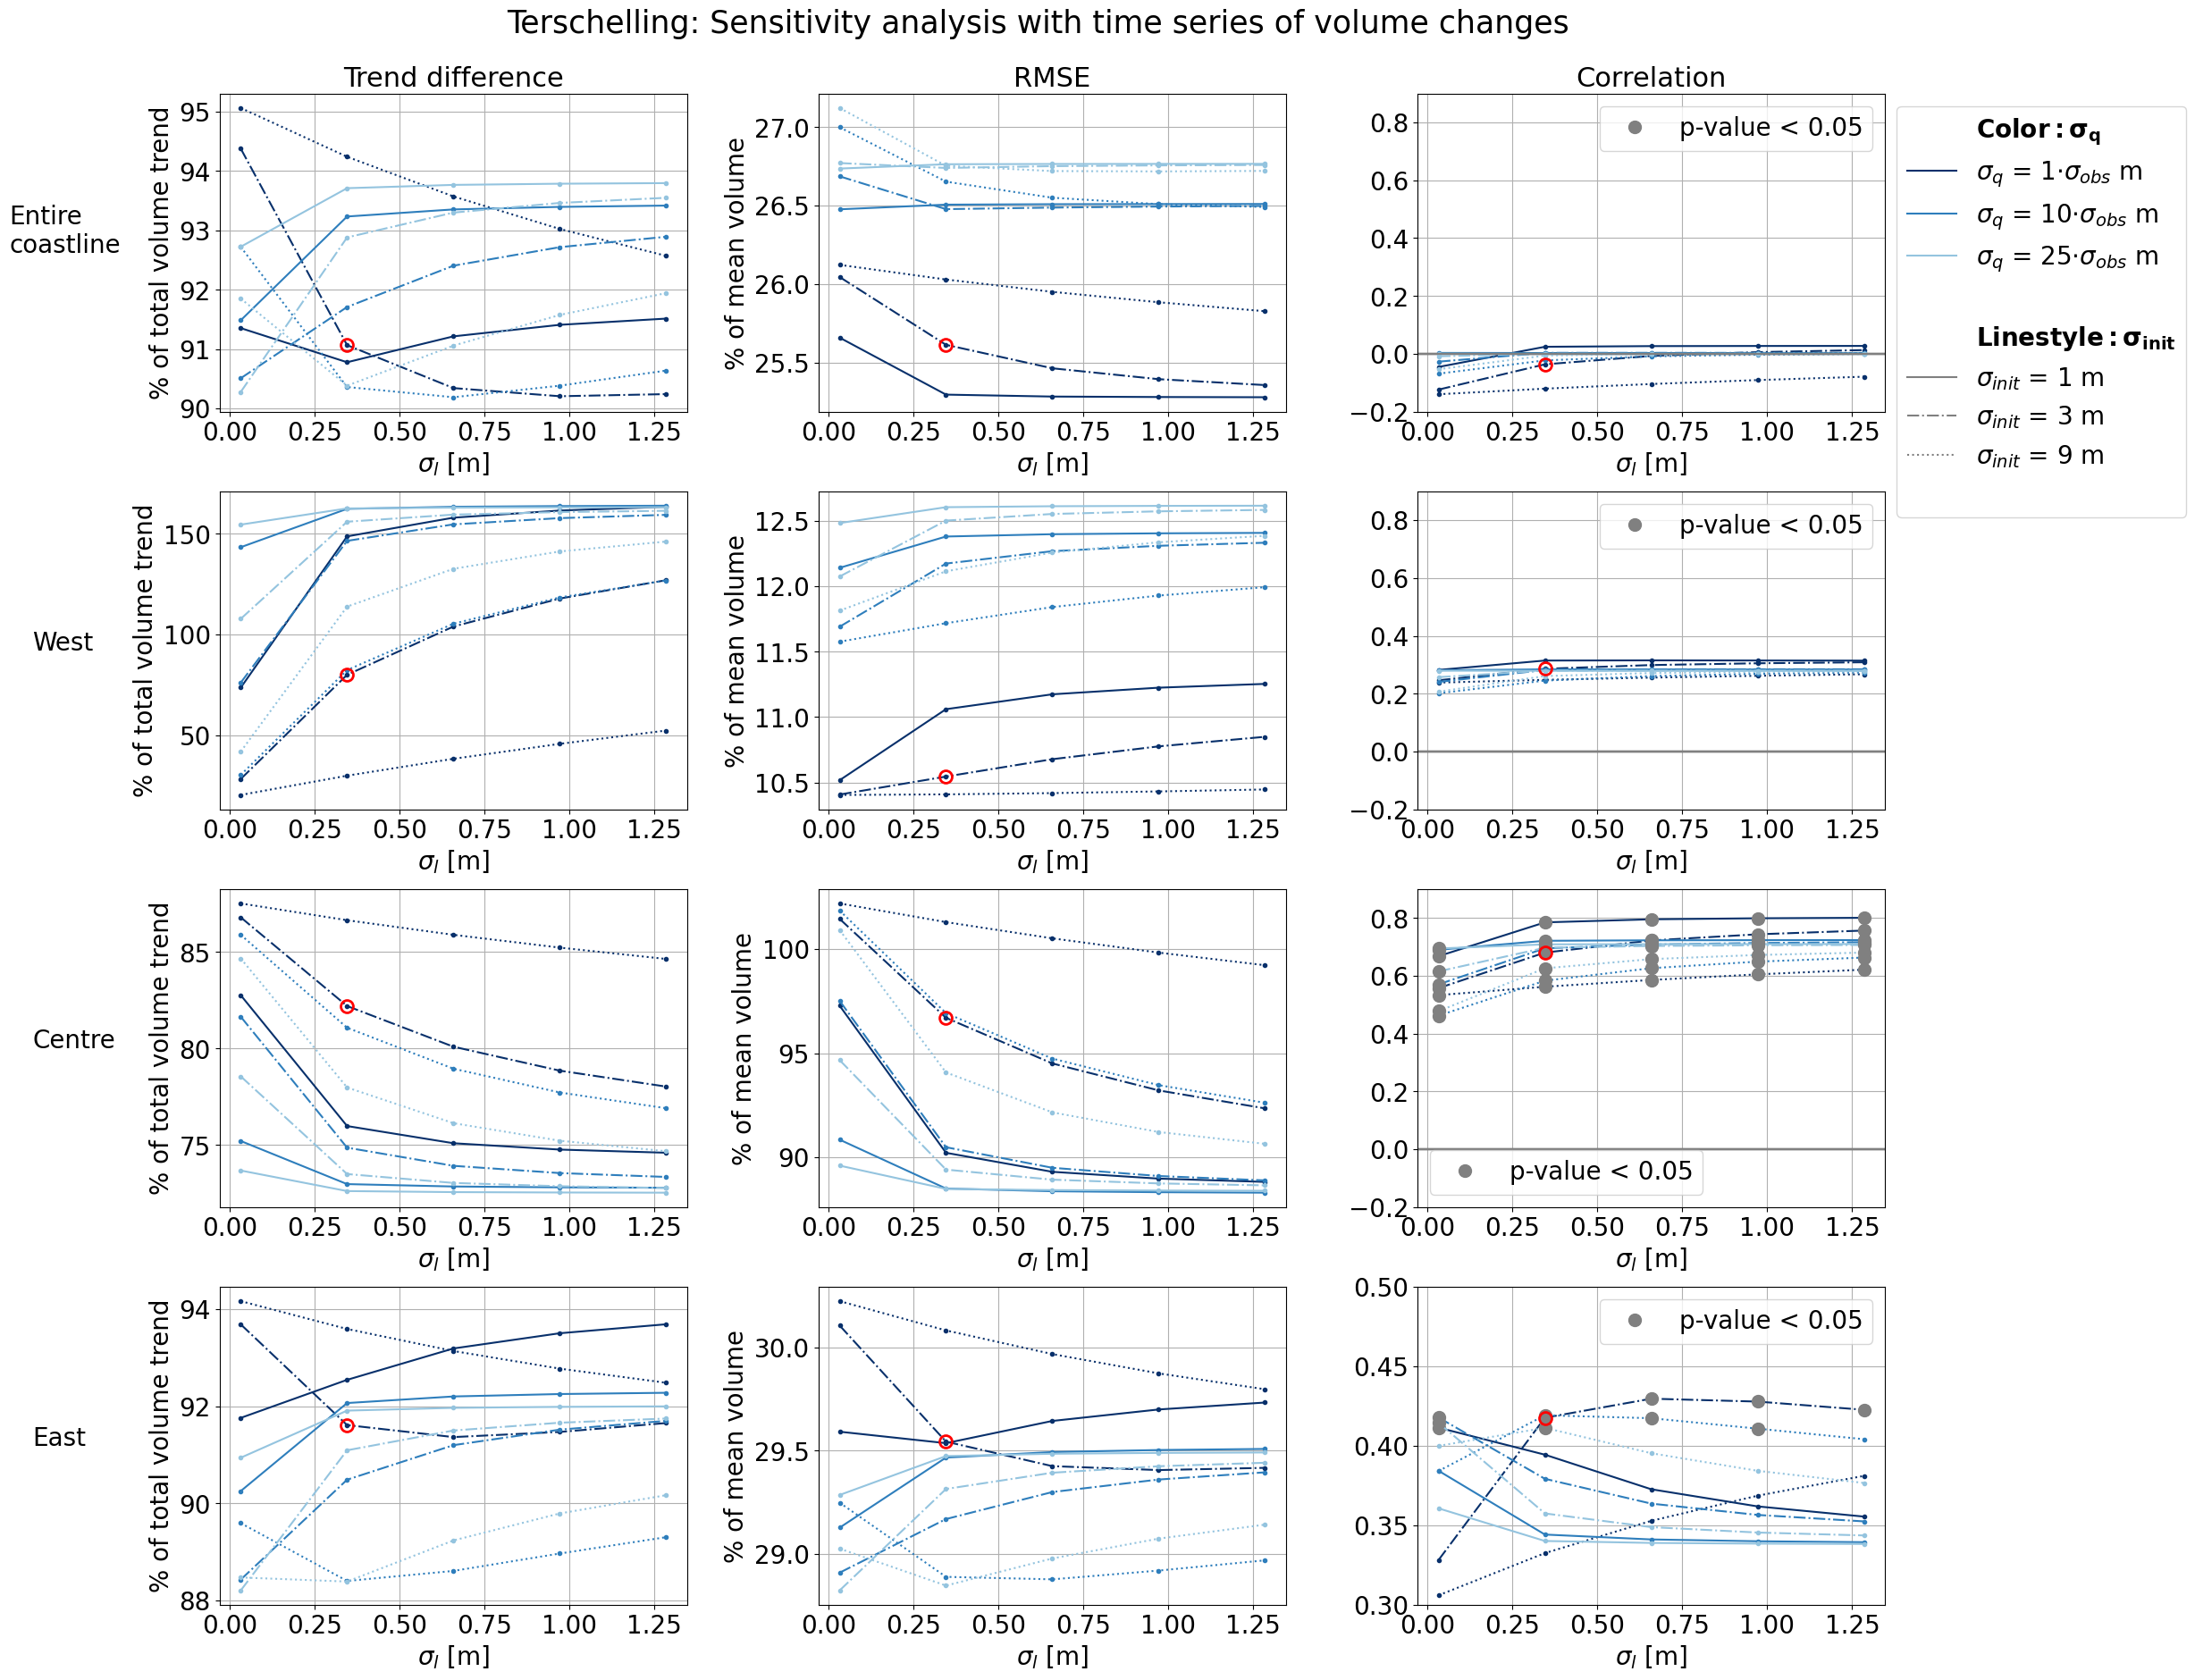

In [31]:
# idx_selected = 20 # index of the parameters selected for validation
idx_selected = 4

fig, axs = plt.subplots(4,3, figsize=(20,18))
fig.tight_layout()
fig.subplots_adjust(hspace=.25, wspace=.28)

## Absolute trend differences
# plot_vol_stats(axs[0,0], trend_diff['all'], area='all', ylabel=r'[m$^3$/year]', title='Trend difference', plot_zero=True)
# plot_vol_stats(axs[1,0], trend_diff['west'], area='west', ylabel=r'[m$^3$/year]', title='', plot_zero=True)
# plot_vol_stats(axs[2,0], trend_diff['center'], area='center', ylabel=r'[m$^3$/year]', title='', plot_zero=True)
# plot_vol_stats(axs[3,0], trend_diff['east'], area='east', ylabel=r'[m$^3$/year]', title='', plot_zero=True)

## Relative trend differences (%)
plot_vol_stats(axs[0,0], trend_diff_perc['all'], area='all', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
plot_vol_stats(axs[1,0], trend_diff_perc['west'], area='west', ylabel='% of total volume trend', title='', plot_zero=False)
plot_vol_stats(axs[2,0], trend_diff_perc['center'], area='center', ylabel='% of total volume trend', title='', plot_zero=False)
plot_vol_stats(axs[3,0], trend_diff_perc['east'], area='east', ylabel='% of total volume trend', title='', plot_zero=False)

mark_selected_param(axs[0,0], idx_selected, trend_diff_perc['all'])
mark_selected_param(axs[1,0], idx_selected, trend_diff_perc['west'])
mark_selected_param(axs[2,0], idx_selected, trend_diff_perc['center'])
mark_selected_param(axs[3,0], idx_selected, trend_diff_perc['east'])

axs[0,0].text(-.45,.5, f'Entire\ncoastline', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(-.4,.5, f'West', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(-.4,.5, f'Centre', transform=axs[2,0].transAxes, fontsize=20)
axs[3,0].text(-.4,.5, f'East', transform=axs[3,0].transAxes, fontsize=20)

# Absolute RMSE
# plot_vol_stats(axs[0,1], rmse_df.T['all'], area='all', ylabel=r'[m$^3$]', title='RMSE')
# plot_vol_stats(axs[1,1], rmse_df.T['west'], area='west', ylabel=r'[m$^3$]', title='')
# plot_vol_stats(axs[2,1], rmse_df.T['center'], area='center', ylabel=r'[m$^3$]', title='')
# plot_vol_stats(axs[3,1], rmse_df.T['east'], area='east', ylabel=r'[m$^3$]', title='')

# mark_selected_param(axs[0,1], idx_selected, rmse_df.T['all'])
# mark_selected_param(axs[1,1], idx_selected, rmse_df.T['west'])
# mark_selected_param(axs[2,1], idx_selected, rmse_df.T['center'])
# mark_selected_param(axs[3,1], idx_selected, rmse_df.T['east'])

# Relative RMSE (%)
ylim_rmse = [0,0.26]
ylim_rmse = None
plot_vol_stats(axs[0,1], rmse_perc['all'], area='all', ylabel='% of mean volume', title='RMSE', ylim=ylim_rmse)
plot_vol_stats(axs[1,1], rmse_perc['west'], area='west', ylabel='% of mean volume', title='', ylim=ylim_rmse)
plot_vol_stats(axs[2,1], rmse_perc['center'], area='center', ylabel='% of mean volume', title='', ylim=ylim_rmse)
plot_vol_stats(axs[3,1], rmse_perc['east'], area='east', ylabel='% of mean volume', title='', ylim=ylim_rmse)

mark_selected_param(axs[0,1], idx_selected, rmse_perc['all'])
mark_selected_param(axs[1,1], idx_selected, rmse_perc['west'])
mark_selected_param(axs[2,1], idx_selected, rmse_perc['center'])
mark_selected_param(axs[3,1], idx_selected, rmse_perc['east'])

ylim_corr = [-.2,.9]
# ylim_corr = None
plot_vol_stats(axs[0,2], corr_df.T['all'], area='all', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
plot_vol_stats(axs[1,2], corr_df.T['west'], area='west', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_vol_stats(axs[2,2], corr_df.T['center'], area='center', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_vol_stats(axs[3,2], corr_df.T['east'], area='east', ylabel='', title='', corr=True, plot_zero=True, ylim=[.3,.5])

mark_selected_param(axs[0,2], idx_selected, corr_df.T['all'])
mark_selected_param(axs[1,2], idx_selected, corr_df.T['west'])
mark_selected_param(axs[2,2], idx_selected, corr_df.T['center'])
mark_selected_param(axs[3,2], idx_selected, corr_df.T['east'])

plot_legend(axs[0,1], c_list, ls_list, factors, std_init_values)
plt.suptitle('Terschelling: Sensitivity analysis with time series of volume changes', y=1.03, fontsize=25);

plt.savefig(f'{path_output}Ters_partun_volume_change_stats.png', dpi=300, bbox_inches='tight')

#### Split figure

### Elevation changes

In [32]:
def plot_elev_stats(ax, stats_data, stats_varname, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            ax.plot(stats_data.sigma_l, stats_data[stats_varname].loc[{'factors':factor, 'std_init':std_init}].median(dim='lon'), ls=ls_list[g], c=c_list[f], marker='.')
            if corr:
                pvalues_box = np.where(stats_data.pvalue.loc[{'factors':factor, 'std_init':std_init}].mean(dim='lon') < 0.05)[0]
                ax.plot(stats_data.sigma_l[idx[pvalues_box]], stats_data.corr.loc[{'factors':factor, 'std_init':std_init}].median(dim='lon')[idx[pvalues_box]], 
                marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')], loc='lower right')
            if ylim is not None:
                ax.set_ylim(ylim)
            if plot_zero:
                ax.axhline(y=0, color='grey')
    ax.set_xlabel(r'$\sigma_{obs}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()

In [33]:
poly_west = pickle.load(open(path_output + f'poly_west_{epsg}.pkl', 'rb'))
poly_center = pickle.load(open(path_output + f'poly_center{epsg}.pkl', 'rb'))
poly_east = pickle.load(open(path_output + f'poly_east{epsg}.pkl', 'rb'))

stats_loc = gpd.GeoDataFrame(geometry=gpd.points_from_xy(all_stats.lon, all_stats.lat))

idx_west, = np.where(stats_loc.intersects(poly_west))
idx_center, = np.where(stats_loc.intersects(poly_center))
idx_east, = np.where(stats_loc.intersects(poly_east))

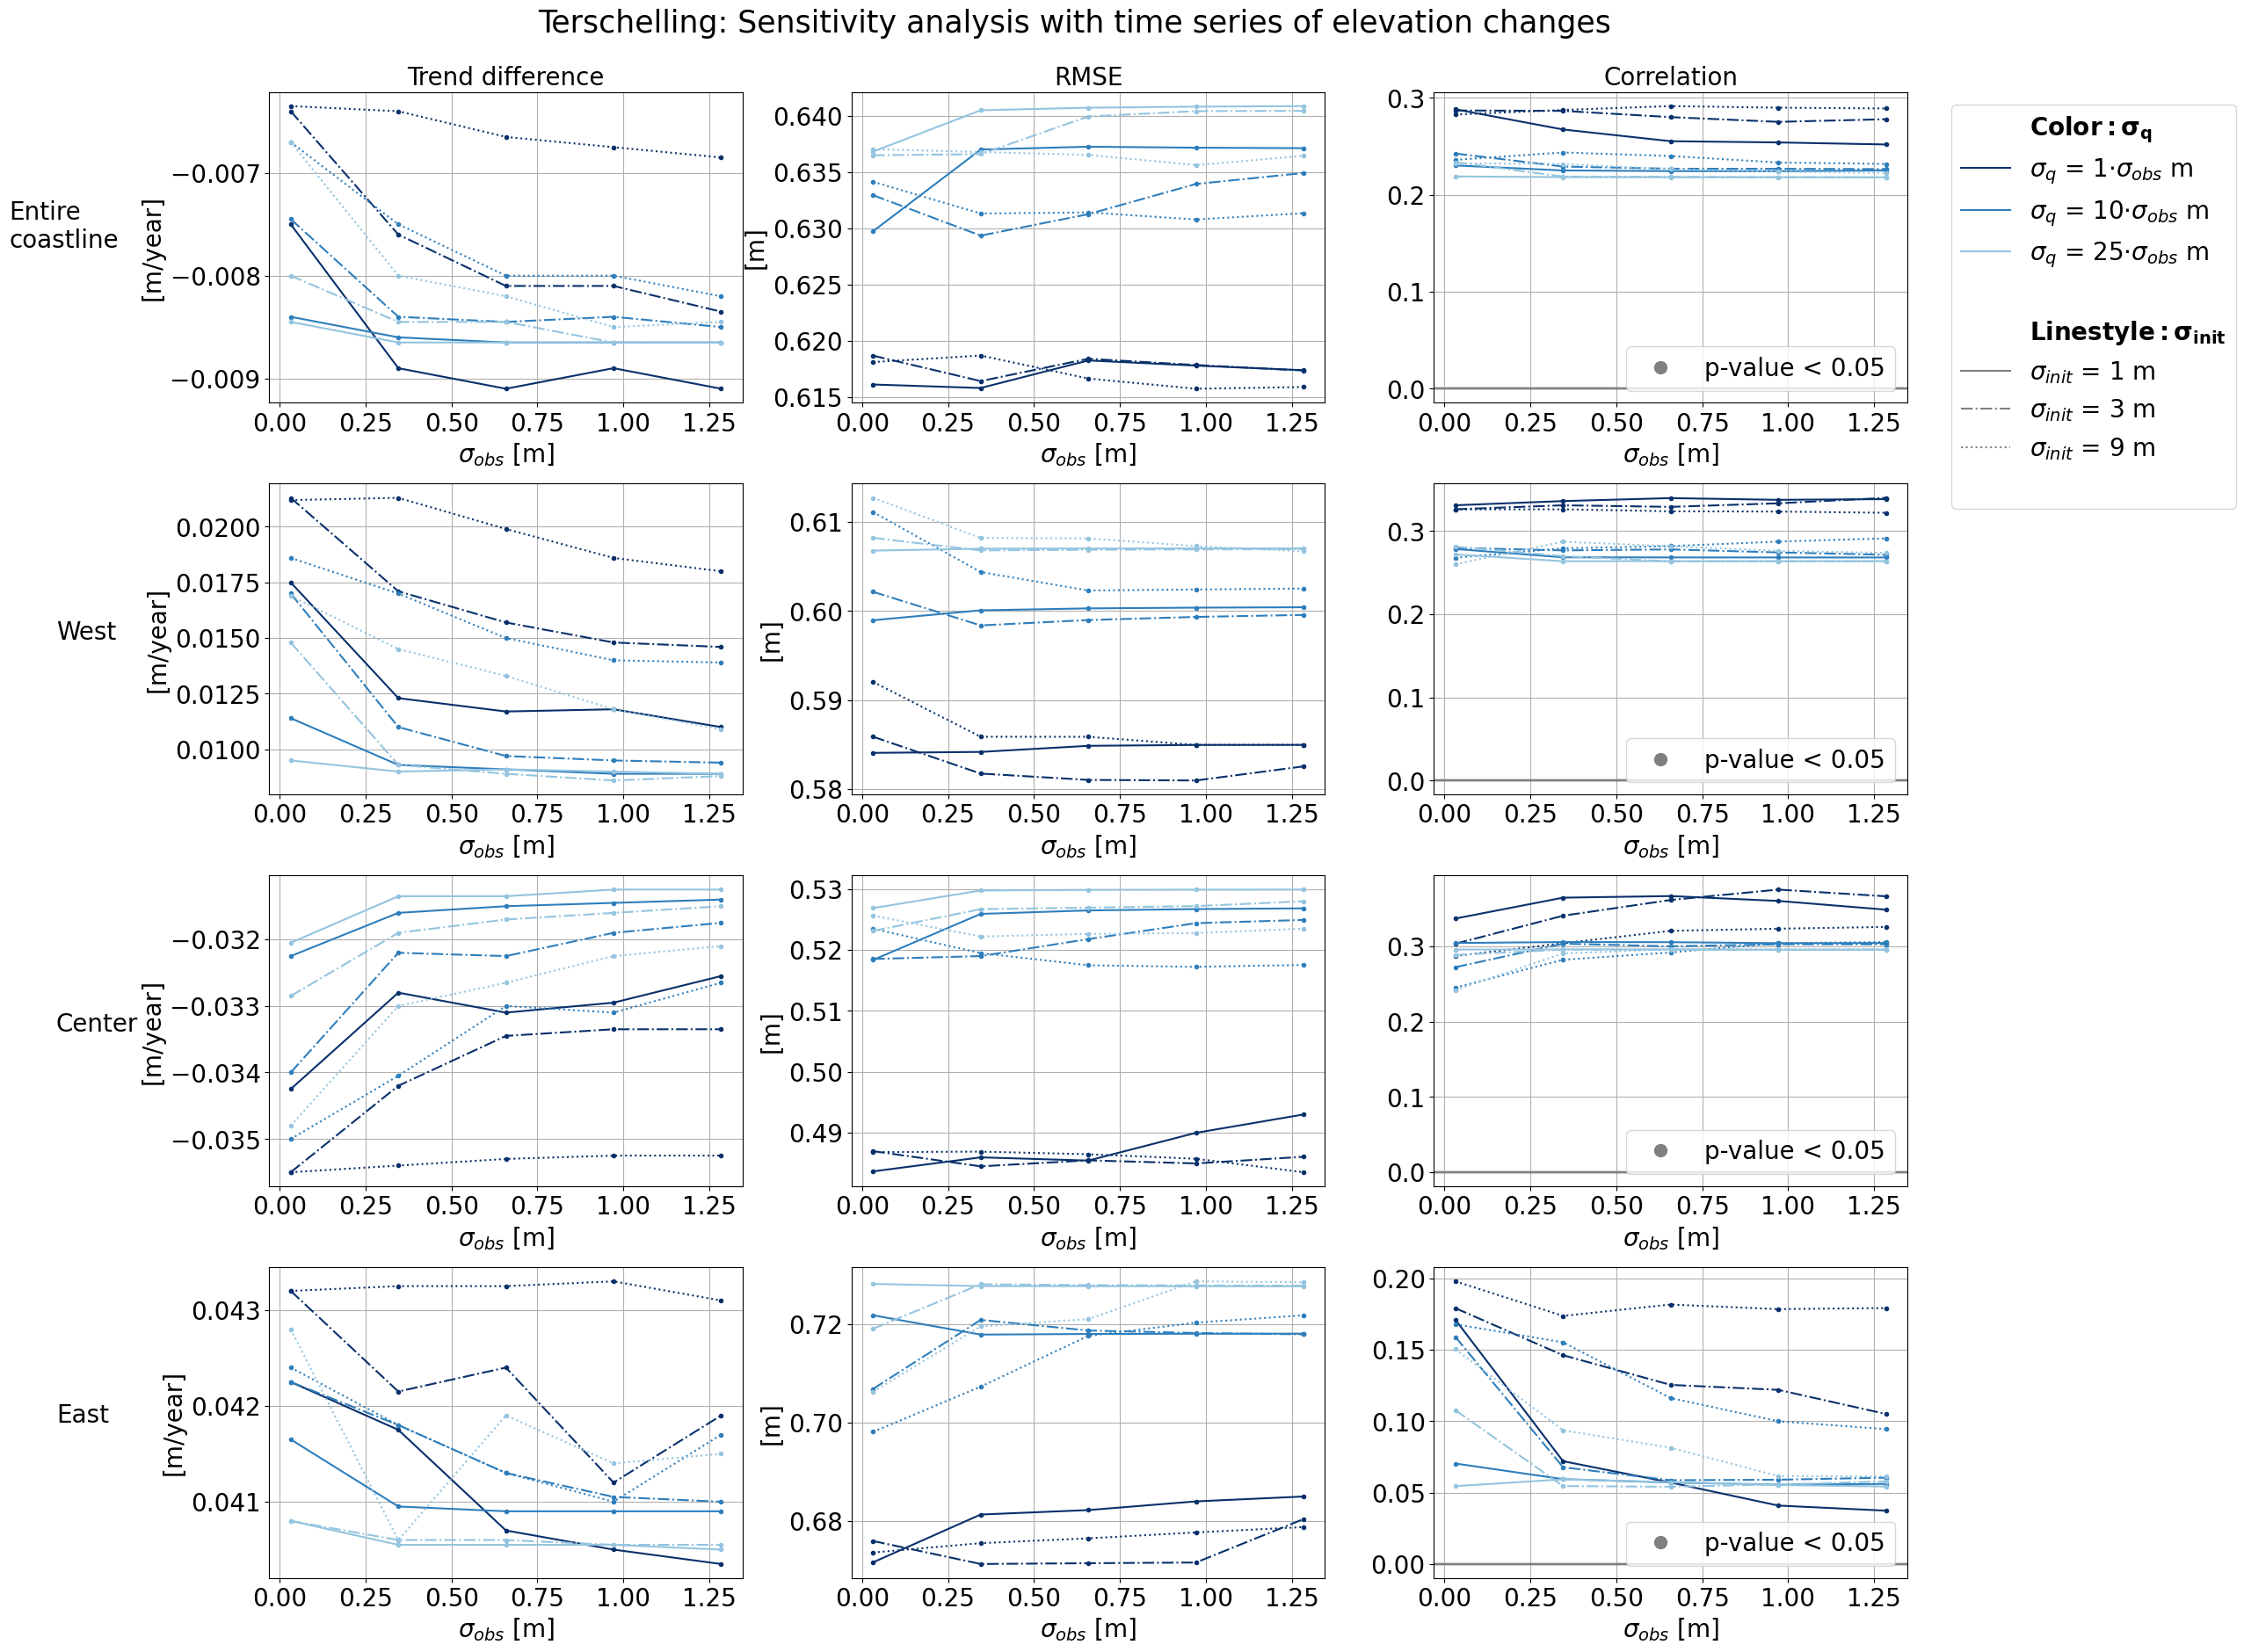

In [34]:
fig, axs = plt.subplots(4,3, figsize=(20,18))
fig.tight_layout()
fig.subplots_adjust(hspace=.26, wspace=.23)

# ylim_tdiff = [-.05, .05]
ylim_tdiff = None
plot_elev_stats(axs[0,0], all_stats, 'trend_diff', ylabel='[m/year]', title='Trend difference', plot_zero=False, ylim=ylim_tdiff)
plot_elev_stats(axs[1,0], all_stats.isel(lon=idx_west), 'trend_diff', ylabel='[m/year]', title='', plot_zero=False, ylim=ylim_tdiff)
plot_elev_stats(axs[2,0], all_stats.isel(lon=idx_center), 'trend_diff', ylabel='[m/year]', title='', plot_zero=False, ylim=ylim_tdiff)
plot_elev_stats(axs[3,0], all_stats.isel(lon=idx_east), 'trend_diff', ylabel='[m/year]', title='', plot_zero=False, ylim=ylim_tdiff)

axs[0,0].text(-.55,.5, f'Entire\ncoastline', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(-.45,.5, f'West', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(-.45,.5, f'Center', transform=axs[2,0].transAxes, fontsize=20)
axs[3,0].text(-.45,.5, f'East', transform=axs[3,0].transAxes, fontsize=20)

# ylim_rmse = [.4,.7]
ylim_rmse = None
plot_elev_stats(axs[0,1], all_stats, 'rmse', ylabel='[m]', title='RMSE', ylim=ylim_rmse)
plot_elev_stats(axs[1,1], all_stats.isel(lon=idx_west), 'rmse', ylabel='[m]', title='', ylim=ylim_rmse)
plot_elev_stats(axs[2,1], all_stats.isel(lon=idx_center), 'rmse', ylabel='[m]', title='', ylim=ylim_rmse)
plot_elev_stats(axs[3,1], all_stats.isel(lon=idx_east), 'rmse', ylabel='[m]', title='', ylim=ylim_rmse)

# ylim_corr = [-.7,.7]
ylim_corr = None
plot_elev_stats(axs[0,2], all_stats, 'corr', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
plot_elev_stats(axs[1,2], all_stats.isel(lon=idx_west), 'corr', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_elev_stats(axs[2,2], all_stats.isel(lon=idx_center), 'corr', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)
plot_elev_stats(axs[3,2], all_stats.isel(lon=idx_east), 'corr', ylabel='', title='', corr=True, plot_zero=True, ylim=ylim_corr)

plot_legend(axs[0,1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Terschelling: Sensitivity analysis with time series of elevation changes', y=1.03, fontsize=25);

plt.savefig(f'{path_output}Ters_partun_elev_change_stats.png', dpi=300, bbox_inches='tight')

#### Split figure

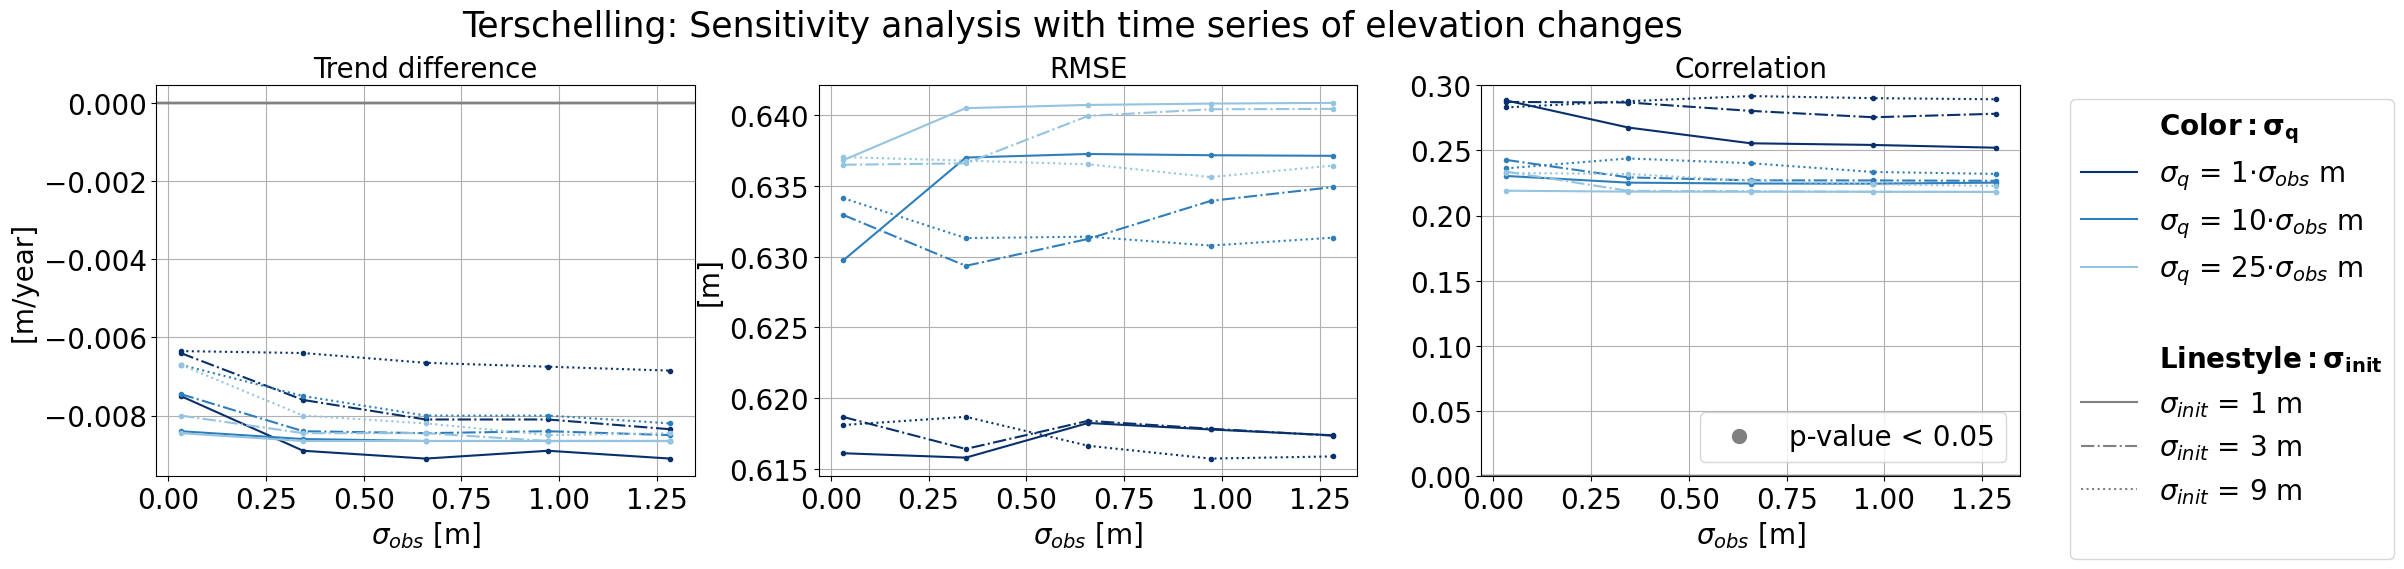

In [35]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.26, wspace=.23)

# ylim_tdiff = [-.05, .05]
ylim_tdiff = None
plot_elev_stats(axs[0], all_stats, 'trend_diff', ylabel='[m/year]', title='Trend difference', plot_zero=True, ylim=ylim_tdiff)

# ylim_rmse = [.4,.7]
ylim_rmse = None
plot_elev_stats(axs[1], all_stats, 'rmse', ylabel='[m]', title='RMSE', ylim=ylim_rmse)

ylim_corr = [0,.3]
plot_elev_stats(axs[2], all_stats, 'corr', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)

plot_legend(axs[1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Terschelling: Sensitivity analysis with time series of elevation changes', y=1.07, fontsize=25);

# plt.savefig(f'{path_output}Ters_entire_coastline_partun_elev_change_stats.png', dpi=300, bbox_inches='tight')